In [1]:
#import datetime as dt
import cftime 
import time
from time import time as timer
#import datetime
# datetime import datetime as py_datetime
import datetime as dt
import numpy as np
import xarray as xr
import pandas as pd

import glob
import os
import re
import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
sys.path.append('fsrc/')
import ens
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts

import state_vector as state


import skimage.measure as sm
from scipy import stats
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial
from scipy.ndimage import gaussian_filter

import netCDF4 as ncdf


import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import LinearSegmentedColormap, to_rgb
import colormaps as cmaps

import json
from pyproj import Proj

from pyDart import dll_2_dxy, dxy_2_dll
import pyDart

from subprocess import *
#from cbook2 import *
import src.plot_src.ctables as ctables
from optparse import OptionParser


def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

## settings for plots - makes them look nicer

#mpl.rcParams.keys()
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0, 'lines.solid_capstyle':'butt',
                     'axes.labelsize':13, 'axes.titlesize':18, 'ytick.labelsize':13, 'xtick.labelsize':13, 'axes.titleweight':'bold'})
ens2nr = {'UH_2-5km': {25: 46, 50: 94, 75: 141, 100: 182, 125: 226, 150: 268}, 
               'dbz': {30: 8, 35: 16, 40: 24, 45: 32, 50: 40, 55: 48}}
    
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04, text_bump =0):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k')
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, text_bump+y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13)


In [6]:
def get_ds(myds, kind, t, mem=None):

    ''' this gets you all the data for single data type at a single time
        you cannot get the full dataset for multiple times and multiple variables'''

    kindID = obs2num[kind]
    ds = myds.copy()
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))

    ds = ds.isel(t=slice(t,t+1))
    
    ds = ds.isel(n=ds[kind].values[0])
    return ds
   


def get_var(myds, var, kind, t=None, tf=None, mem=None, keep_dim=True, drop_outliers=True, drop_inliers=False):
    ''' returns a single variable. for a single data type. Keep_dim means you keep the time dimension.
        if t == None, whole dataset returned. if mem=None, all members returned (and dimensions are retained)
        if t!= None but tf == None, then only a single index (t) is returned. Else, a slice between t and tf is returned.'''

    ds = myds.copy()

    if drop_outliers:
        variable = ds[var].values
        variable[ds.outlier.values>3] = np.nan
        if drop_inliers:
            variable[ds.outlier.values<0.25] = np.nan

        if ((var== 'Hxf') | (var== 'Hxf_post')):
            ds[var] = (('t', 'n', 'ne'), variable)
        else:
            ds[var] = (('t', 'n'), variable)
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))
    
    if t!= None:
        if tf == None:tf = t+1
        ds = ds.isel(t=slice(t,tf))
    
    if len(ds.t)==1:
        ds = ds.isel(n=ds[kind].values[0])
        mydata = ds[var].values
        mydata = mydata[np.isnan(mydata) == False]
    
    if (len(ds.t)>1) & (keep_dim==False):
        mydata = ds[var].values[ds[kind].values]
        mydata = mydata[np.isnan(mydata) == False]
    
    
    if (len(ds.t)>1) & (keep_dim) & ((var!= 'Hxf') & (var!= 'Hxf_post')):  
        temp = []
        sizes = []
    
        mydata = np.zeros([len(ds.t), 100000])*np.nan
    
        for i in range(len(ds.t)):
           
            v = ds[var].values[i][ds[kind].values[i]]
            sizes.append(len(v))
            mydata[i, :len(v)] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
    
    if (len(ds.t)>1) & (keep_dim) & ((var== 'Hxf') | (var== 'Hxf_post')) :  
        temp = []
        sizes = []
    
        if mem !=None: mydata = np.zeros([len(ds.t), 100000])*np.nan
        else:  mydata = np.zeros([len(ds.t), 100000, len(ds.ne)])*np.nan
        for i in range(len(ds.t)):
            for n in range(len(ds.ne)):
                v = ds[var].values[i,:,n][ds[kind].values[i]]
                sizes.append(len(v))
                mydata[i, :len(v), n] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
        

    return np.array(mydata)



# def plot_circle(ax, rx, ry):
#     for r in [7.5, 9, 12, 15, 18]:
#         ax.add_patch(plt.Circle((rx,ry), r, fill=False, edgecolor='k', alpha=0.5))
 

In [2]:
PRIOR =True
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R0_V2/'

time = dt.datetime(2024,5,8,21,21)

with open(f'{fpath}letkf.exp', 'rb') as f:exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:21:00
you requested prior files.... searching for prior files.

 ==> FindRestartFile:  Found time 6660 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R0_V2/member001/cm1_prior_000029.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 21:21:00 


 Wallclock time for serial read netCDF ensemble files: 30.91  sec

 Wallclock time to convert from C to A grid: 0.684  sec

 Wallclock time to create ensemble means: 1.27  sec

 Wallclock time to read arrays from netCDF ensemble files: 33.644  sec

 Wallclock time to create coordinates: 0.0  sec


In [7]:
exp = 'C3_5L09_R0_V2'
var = 'DBZ'
ens_var = 'DBZ'

ds = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/AllPrior_Post.nc", decode_timedelta=True)
inlier =False
times_obs = [pd.Timestamp(t) for t in ds.time.values] 


full_ens = ens_state[ens_var][:-1,:,:,:]
ens_pert = full_ens - full_ens.mean() # i guess just use one value? along height may be better though?
#ens_pert = np.where(full_ens >= 20, ens_pert, np.nan)

# find all values for reflectivity, regardless of variable you are doing
ref_value = get_var(ds, 'value','DBZ', drop_inliers=inlier)


val = get_var(ds, 'value', var, drop_inliers=inlier)
xob = get_var(ds, 'x', var, drop_inliers=inlier)
yob = get_var(ds, 'y', var, drop_inliers=inlier)
zob = get_var(ds, 'z', var, drop_inliers=inlier)

#Hxfbar = get_var(ds, 'Hxfbar', var,drop_inliers=inlier)
Hxf = get_var(ds, 'Hxf', var, drop_inliers=inlier)

#d = val[:,:,np.newaxis] - Hxf
d = Hxf - np.nanmean(Hxf)

ti = findnearest(times_obs, time)

### NEW - 2dbz cref masl
obs = xr.open_dataset('/work/jessica.mcdonald/NR_radar_obs/3km_superobs_multi.nc') # use 3km obs so that the x/y grids align
obst = [pd.Timestamp(t) for t in obs.time.values] 
obs_ti = findnearest(obst, time)
REF2D = obs.REF[obs_ti].max(axis=0).values
yref, xref = np.where(REF2D>=20)
pts = np.array([yref, xref]).T

In [8]:
print(ens_var)
full_ens = ens_state[ens_var][:-1,:,:,:]
ens_pert = full_ens - full_ens.mean() # i guess just use one value? along height may be better though?

total_cor   = []
total_Hdist = []
total_Vdist = []
total_dist  = []



# don't go above zcutoff (10 km) + vertical localization radius, so 17 km for me, k=39 gives 17.5, k=38 is 16.9km
zn = np.arange(39)

zh3, yh3, xh3 = np.meshgrid(ens_state['zc'][:len(zn)]/1000,ens_state['xc'][:]/1000,ens_state['yc'][:]/1000, indexing='ij')
     

for ni in [1510]:#range(len(xob[ti])):  # good ones: 40, 710, 205, 1510
    if ni%10 == 0: print(ni, end=',')
        
    if np.isnan(xob[ti, ni]) ==False:

        #ni = 40#405#0

        if ref_value[ti, ni] >= 20: # only use obs where refl > 20
        
            
            d_i = d[ti, ni, :] # 36 values
            
            x_i = xob[ti, ni]/1000
            y_i = yob[ti, ni]/1000
            z_i = zob[ti, ni]/1000
        
            z_ens = findnearest(ens_state['zc'][:], z_i)
            
            
            ### subset test
            xh, yh, zh =ens_state['xc'][:]/1000,ens_state['yc'][:]/1000,ens_state['zc'][:]/1000
            
            cors = np.empty([len(zn), 128, 128])*np.nan

            for p in pts: # only loop over points where cref > 20
                for zz in zn:
                    xx, yy = p[1], p[0]
                    vals = ens_pert[:, zz, yy, xx]
                    cors[zz, yy,xx] = np.corrcoef(d_i, vals)[0,1]

            H_dist = np.hypot(xh3 - x_i, yh3 - y_i)
            V_dist = abs(zh3 - z_i)
            total = np.hypot(xh3 - x_i, yh3 - y_i, zh3 - z_i)
        
        # add to full dataset now
        mask = np.isnan(cors) == False
        total_cor.extend(cors[mask])
        total_Hdist.extend(H_dist[mask])
        total_Vdist.extend(V_dist[mask])
        total_dist.extend(total[mask])

# datadict = {'corr': total_cor, 'Hdist':total_Hdist, 'Vdist':total_Vdist, 'totaldist': total_dist}
# df = pd.DataFrame(datadict)
# name = f'{fpath}corr_{var}_{ens_var}_20dbz.csv'
# df.to_csv(name, index=None)

DBZ
1510,

/home/jessica.mcdonald/miniconda3/envs/letkf_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jessica.mcdonald/miniconda3/envs/letkf_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


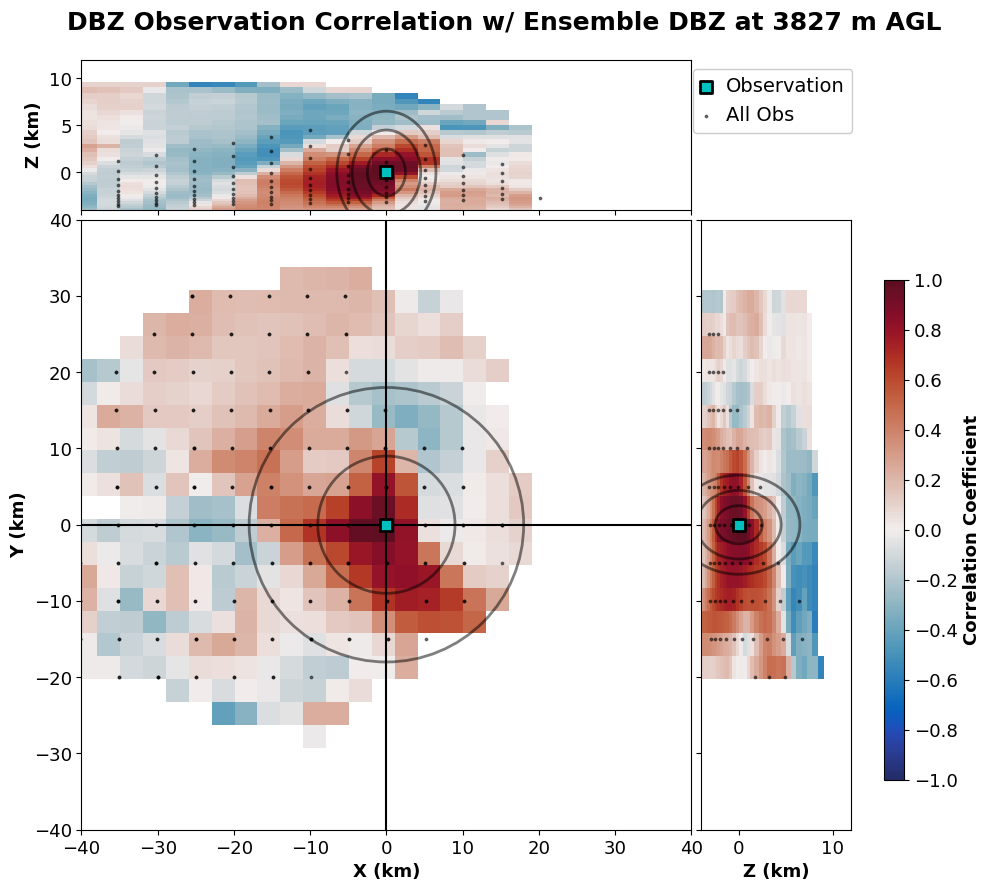

In [9]:
def plot_radar(ax, rx, ry, rs=[10]):

    ax.scatter(rx,ry, color='k')

    for r in rs:
        #ax.add_patch(plt.Circle((rx,ry), r, fill=False, edgecolor='w', alpha=1, linewidth=2))
        ax.add_patch(plt.Circle((rx,ry), r, fill=False, edgecolor='k', alpha=0.5, linewidth=2))
        
from mpl_toolkits.axes_grid1 import make_axes_locatable
def make_plan_plot():
    fig, main_ax = plt.subplots(figsize=(10,10))#, facecolor='none')
    divider = make_axes_locatable(main_ax)
    top_ax = divider.append_axes("top", 1.5, pad=0.1, sharex=main_ax)
    right_ax = divider.append_axes("right", 1.5, pad=0.1, sharey=main_ax)

    # make some labels invisible
    top_ax.xaxis.set_tick_params(labelbottom=False)
    right_ax.yaxis.set_tick_params(labelleft=False)

    main_ax.set_xlabel('X (km)')
    main_ax.set_ylabel('Y (km)')
    top_ax.set_ylabel( 'Z (km)')
    right_ax.set_xlabel('Z (km)')
    main_ax.set_aspect('equal')
    
    return fig, main_ax, right_ax, top_ax


z_ens = findnearest(zh3[:,0,0], z_i)
crossx = findnearest(xh3[0,0,:], x_i)
crossy = findnearest(yh3[0,:,0], y_i)


fig, main_ax, right_ax, top_ax =make_plan_plot()

cmap = cmaps.balance.cut(.05, 'left').cut(.05, 'right')#.cut(.25, 'centre')


top_ax.pcolormesh(xh3[:,0,:]-x_i, zh3[:,0,:]-z_i, cors[:, crossy, :], vmin = -1, vmax = 1, cmap=cmap )
right_ax.pcolormesh(zh3[:,:,0]-z_i, yh3[:,:,0]-y_i, cors[:, :,crossx], vmin = -1, vmax = 1, cmap=cmap )

im=main_ax.pcolormesh(xh-x_i, yh-y_i, cors[z_ens], vmin = -1, vmax = 1, cmap=cmap )

#main_ax.contour(xh-x_i, yh-y_i, cors[z_ens], levels=[.6,.8], colors='k')

for ax in [main_ax, right_ax, top_ax]: ax.scatter(0,0, color='c', ec='k', s=80, linewidth=2, marker='s', label='Observation', zorder=100)
    
plot_radar(main_ax, 0,0, [ 9, 18])
plot_radar(top_ax, 0,0, [2.5, 4.5, 6.5])
plot_radar(right_ax, 0,0, [2.5, 4.5, 6.5])


main_ax.set_xlim(-40,40)
main_ax.set_ylim(-40,40)
top_ax.set_ylim(np.min([0, -1*z_i]), np.max([10, z_i+8]))
right_ax.set_xlim(np.min([0, -1*z_i]), np.max([10, z_i+8]))


main_ax.scatter(xob[ti, (ref_value[ti] >= 20) & (abs((zob[ti]/1000 - z_i)) < 1)]/1000 - x_i, yob[ti,(ref_value[ti] >= 20) & (abs((zob[ti]/1000 - z_i)) < 1)]/1000 - y_i, 
    color='k', s=3, alpha=0.5, label=f'All Obs')

top_ax.scatter(xob[ti, (ref_value[ti] >= 20) & (abs((yob[ti]/1000 - y_i)) < 1) ]/1000 - x_i, zob[ti,(ref_value[ti] >= 20) & (abs((yob[ti]/1000 - y_i)) <1) ]/1000 - z_i, 
               color='k', s=3, alpha=0.5, label=f'All Obs')


right_ax.scatter(zob[ti, (ref_value[ti] >= 20) & (abs((xob[ti]/1000 - x_i)) < 1) ]/1000 - z_i, yob[ti,(ref_value[ti] >= 20) & (abs((xob[ti]/1000 - x_i)) <1) ]/1000 - y_i, 
               color='k', s=3, alpha=0.5, label=f'All Obs')
    
fig.suptitle(f'{var} Observation Correlation w/ Ensemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL', fontsize=18, weight='bold', y=.93, x=.55)
top_ax.legend(fontsize=14, loc=1, bbox_to_anchor=(1.28, 1), handlelength=.5)


main_ax.axhline(0, color='k')
main_ax.axvline(0, color='k')

cbar_ax = fig.add_axes([0.93, 0.16, 0.02, 0.5])
cbar = plt.colorbar(im,  cax=cbar_ax)
cbar.set_label('Correlation Coefficient', weight='bold')
cbar.set_ticks(np.arange(-1, 1.2, .2))
# for lev in [0.4, 0.6, 0.8]:
#     cbar.ax.axhline(lev, color='k')
#     cbar.ax.axhline(-1*lev, color='k')

In [75]:
# from scipy.spatial import ConvexHull, Delaunay
# import scipy.ndimage as ndimage


# # create a mask for where observation reflectivity is > 20 
# obs = xr.open_dataset('/work/jessica.mcdonald/NR_radar_obs/5km_superobs_multi.nc')
# obst = [pd.Timestamp(t) for t in obs.time.values] 
# obs_ti = findnearest(obst, time)
# full_ref_field = obs.REF[obs_ti].values

# labeled_array, num_features = sm.label(full_ref_field  >= 20,connectivity=3,return_num=True)
# OBS = sm.regionprops_table(labeled_array, properties=['area','coords' ])
# df = pd.DataFrame(OBS)

# coords = df.iloc[0]['coords']    
# all_z = obs.altitude.values[coords[:,0],coords[:,1],coords[:,2]]
# all_y = obs.xh.values[coords[:,1]]
# all_x = obs.xh.values[coords[:,2]]
# all_p1 = np.array([all_z, all_y, all_x]).T/1000
# h1 = ConvexHull(all_p1)


# coords = df.iloc[1]['coords']    
# all_z = obs.altitude.values[coords[:,0],coords[:,1],coords[:,2]]
# all_y = obs.xh.values[coords[:,1]]
# all_x = obs.xh.values[coords[:,2]]
# all_p2 = np.array([all_z, all_y, all_x]).T/1000
# h2 = ConvexHull(all_p2)

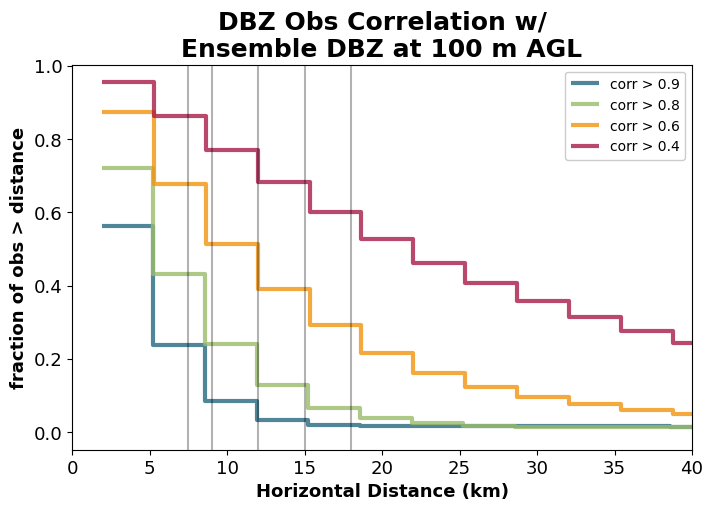

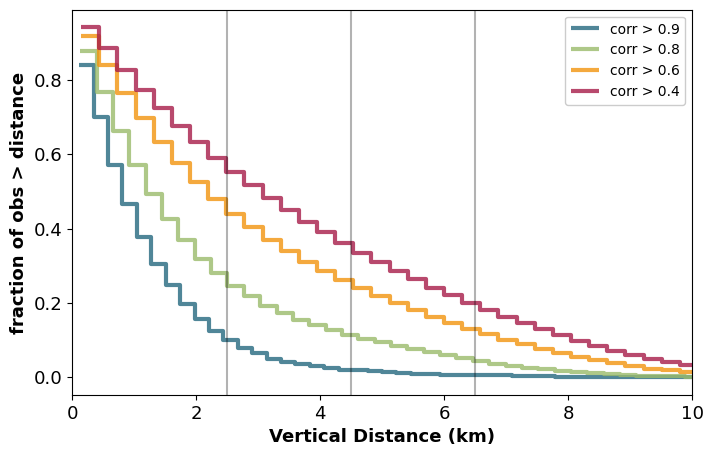

In [145]:
colors = cmaps.pride(np.linspace(.2, .8, 4))

levs = [.9, .8, .6, .4]

fig = plt.figure(figsize=(8, 5))
for i,lev in enumerate(levs):

    mask80 = abs(np.array(total_cor)) >= lev
    data = np.array(total_Hdist)[mask80]
    
    pdf, bin_edges = np.histogram(
       data,        # array of data
       bins=50,    # specify the number of bins for distribution function
       density=True # True to return probability density function (pdf) instead of count
       )
    
    cdf = np.cumsum(pdf*np.diff(bin_edges))
    bins = bin_edges + (bin_edges[1]-bin_edges[0])/2
    plt.plot(bins[:-1], 1-cdf, drawstyle='steps-post' , label=f'corr > {lev}', color=colors[i], lw=3, alpha=0.8)
for l in [7.5, 9, 12, 15, 18]:
    plt.axvline(l, color='k', alpha=0.3)
#plt.axhline(.5)
plt.legend()
plt.xlim(0, 40)
plt.xlabel('Horizontal Distance (km)')
plt.ylabel('fraction of obs > distance')
plt.title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')
plt.show()


fig = plt.figure(figsize=(8, 5))
for i,lev in enumerate(levs):

    mask80 = abs(np.array(total_cor)) >= lev
    data = np.array(total_Vdist)[mask80]
    
    pdf, bin_edges = np.histogram(
       data,        # array of data
       bins=50,    # specify the number of bins for distribution function
       density=True # True to return probability density function (pdf) instead of count
       )
    
    cdf = np.cumsum(pdf*np.diff(bin_edges))
    bins = bin_edges + (bin_edges[1]-bin_edges[0])/2
    plt.plot(bins[:-1], 1-cdf, drawstyle='steps-post' , label=f'corr > {lev}', color=colors[i], lw=3, alpha=0.8)
for l in [2.5, 4.5, 6.5]:
    plt.axvline(l, color='k', alpha=0.3)
#plt.axhline(.5)
plt.legend()
plt.xlim(0, 10)
plt.xlabel('Vertical Distance (km)')
plt.ylabel('fraction of obs > distance')
plt.show()

In [5]:
name = f'{fpath}corr_{var}_{ens_var}_20dbz.csv'
df = pd.read_csv(name)

In [11]:
df['corr'].values[0:s]

array([-0.25847473, -0.18179134, -0.11629954, ...,  0.16732475,
        0.30569288,  0.06320377])

(0.0, 6.0)

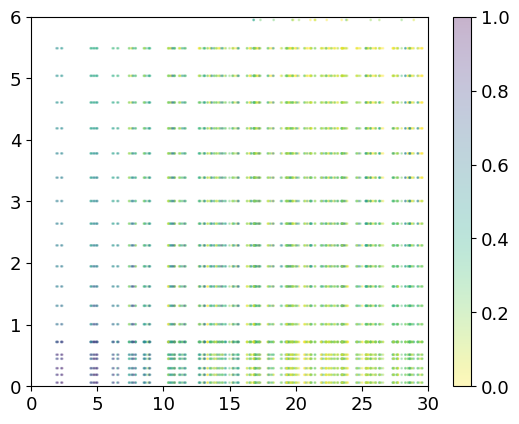

In [12]:

s=10000
plt.scatter(df.Hdist[0:s], df.Vdist[0:s], c=df['corr'][0:s], norm=plt.Normalize(vmin=0, vmax=1), cmap="viridis_r", s=1, alpha=0.3)
plt.colorbar()
plt.xlim(0, 30)
plt.ylim(0, 6)

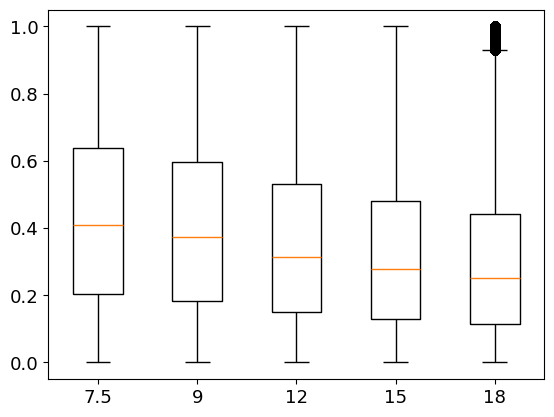

In [31]:
hor = [7.5, 9, 12, 15, 18]#np.arange(0, 30, .5)
ch = []
count = []
for h in hor:
    #print(h)
    try:
        c = abs(df['corr'].values[df.Hdist <= h])
        ch.append(c)
        count.append(len(c))
    except:
        #print('error')
        ch.append(np.nan)
        count.append(np.nan)

plt.boxplot(ch);
plt.xticks([1,2,3,4,5], hor);

In [13]:
hor = [7.5, 9, 12, 15, 18]
vert = [2.5, 4.5, 6.5]

cor_grid = np.zeros([len(hor), len(vert)])
count_grid = np.zeros([len(hor), len(vert)])

for hi, h in enumerate(hor):
    for vi, v in enumerate(vert):
        c = abs(df['corr'].values[(df.Hdist <= h)&(df.Vdist <=v)])
        cor_grid[hi, vi] = np.percentile(c,50)
        count_grid[hi,vi] = len(c)

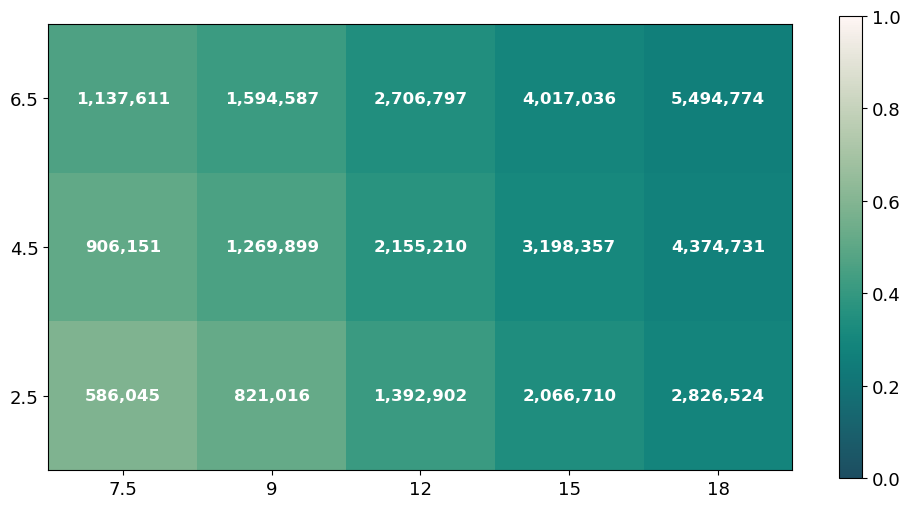

In [44]:
fig = plt.figure(figsize=(12,6))
plt.gca().set_aspect('equal')
xg, yg = np.meshgrid(hor, vert)
plt.pcolormesh(cor_grid.T, vmin=0, vmax=1, cmap=cmaps.tempo_r.cut(0.2, 'left'))


for hi, h in enumerate(hor):
    for vi, v in enumerate(vert):
        plt.text(hi+0.5, vi+0.5, f'{count_grid[hi, vi]:,.0f}', ha='center', va='center', fontsize=12, weight='bold', color='w')



plt.xticks(np.arange(len(hor))+0.5, hor);
plt.yticks(np.arange(len(vert))+0.5, vert);
plt.colorbar()

2.5
4.5
6.6


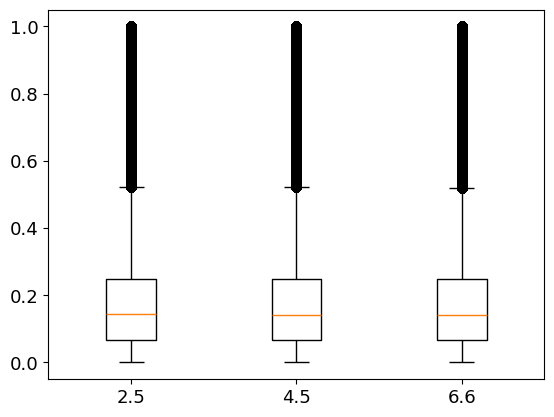

In [34]:
vert = [2.5, 4.5, 6.5]#np.arange(0, 30, .5)
ch = []
count = []
for v in vert:
    print(v)
    try:
        c = abs(df['corr'].values[df.Vdist <= v])
        ch.append(c)
        count.append(len(c))
    except:
        #print('error')
        ch.append(np.nan)
        count.append(np.nan)

plt.boxplot(ch);
plt.xticks([1,2,3], vert);

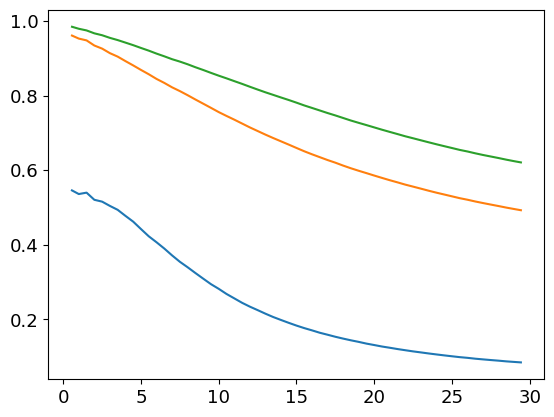

In [23]:
plt.plot(hor, [np.nanpercentile(ch[i], 50) for i in np.arange(0, len(hor))])
plt.plot(hor, [np.nanpercentile(ch[i], 90) for i in np.arange(0, len(hor))])
plt.plot(hor, [np.nanpercentile(ch[i], 95) for i in np.arange(0, len(hor))])

In [ ]:
hor = np.arange(0.1, 30, .1)
ch = []
for h in hor:
   # mask = (total_Hdist < h+.05) & (total_Hdist > h-.05)
    try:
        c = total_cor[np.abs((total_Hdist - h)) <= .1]
        ch.append(np.percentile(c, 90))
    except:
        ch.append(np.nan)

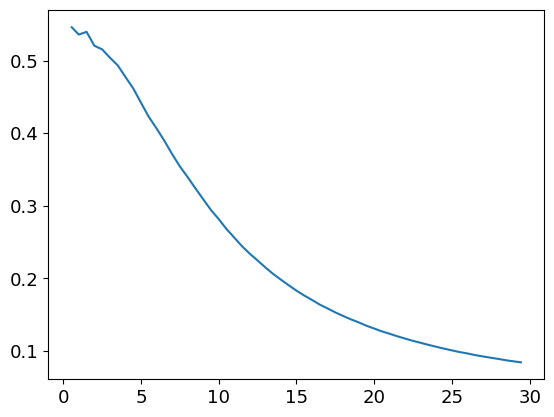

In [18]:
plt.plot(hor, ch)

In [165]:
total_cor[np.where((total_Hdist < h+.05) & (total_Hdist > h-.05))]

TypeError: list indices must be integers or slices, not tuple

In [167]:
h

np.float64(0.0)

In [166]:
np.where((total_Hdist < h+.05) & (total_Hdist > h-.05))

(array([], dtype=int64),)

In [160]:
h+.05

np.float64(0.05)

3.9713108989108257


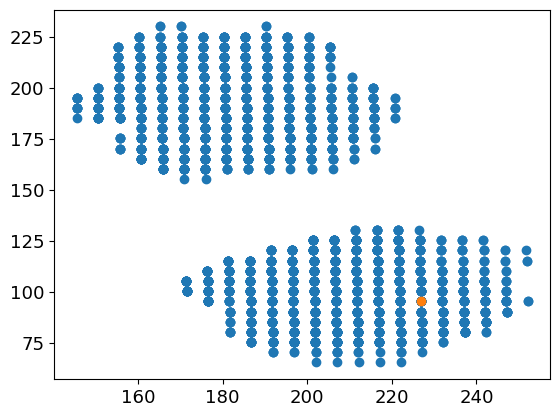

In [237]:
plt.scatter(xob[ti]/1000, yob[ti]/1000)
ni=109
ni=75
ni=1510
plt.scatter(xob[ti, ni]/1000, yob[ti, ni]/1000)
print(zob[ti, ni]/1000)

(-29.74999803863443, 210.25000196136557)

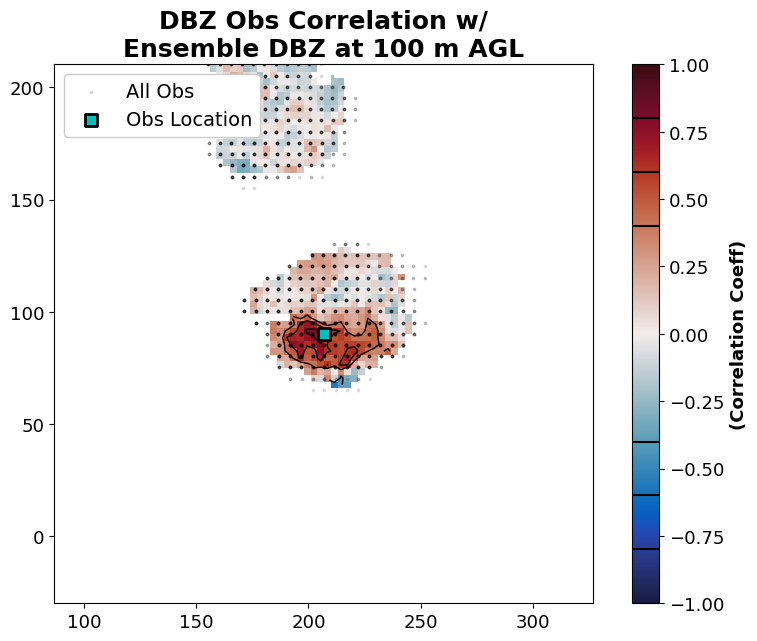

In [47]:


xh, yh = np.meshgrid(ens_state['xc'][:]/1000,ens_state['yc'][:]/1000)

fig, ax = plt.subplots(1,1,figsize=(10,7))
ax.set_aspect('equal')

#im=plt.pcolormesh(xh, yh, abs(cors), vmin = 0, vmax = 1, cmap=cmaps.red2b)
im=plt.pcolormesh(xh, yh, cors[z_ens], vmin = -1, vmax = 1, cmap=cmaps.balance)

plt.contour(xh, yh, abs(cors[z_ens]),levels=[0.4, 0.6, 0.8], colors='k', linewidths=1)

plt.scatter(xob[ti]/1000, yob[ti]/1000, color='k', s=3, alpha=0.1, label=f'All Obs')

plt.scatter(x_i, y_i , color='c', ec='k', s=80, linewidth=2, marker='s', label='Obs Location', zorder=100)


cbar = plt.colorbar(im)
cbar.set_label('(Correlation Coeff)', weight='bold')
for lev in [0.4, 0.6, 0.8]:
    cbar.ax.axhline(lev, color='k')
    cbar.ax.axhline(-1*lev, color='k')
    
plt.title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')
plt.legend(fontsize=14, loc=2)

plt.xlim(x_i-120, x_i+120)
plt.ylim(y_i-120, y_i+120)

# plt.xlim(xh_ob-80, xh_ob+80)
# plt.ylim(yh_ob-80, yh_ob+80)

In [65]:
crossx = findnearest(xh3[0,0,:], x_i)
crossy = findnearest(yh3[0,:,0], y_i)

In [96]:
z_i

np.float64(0.6082051973975194)

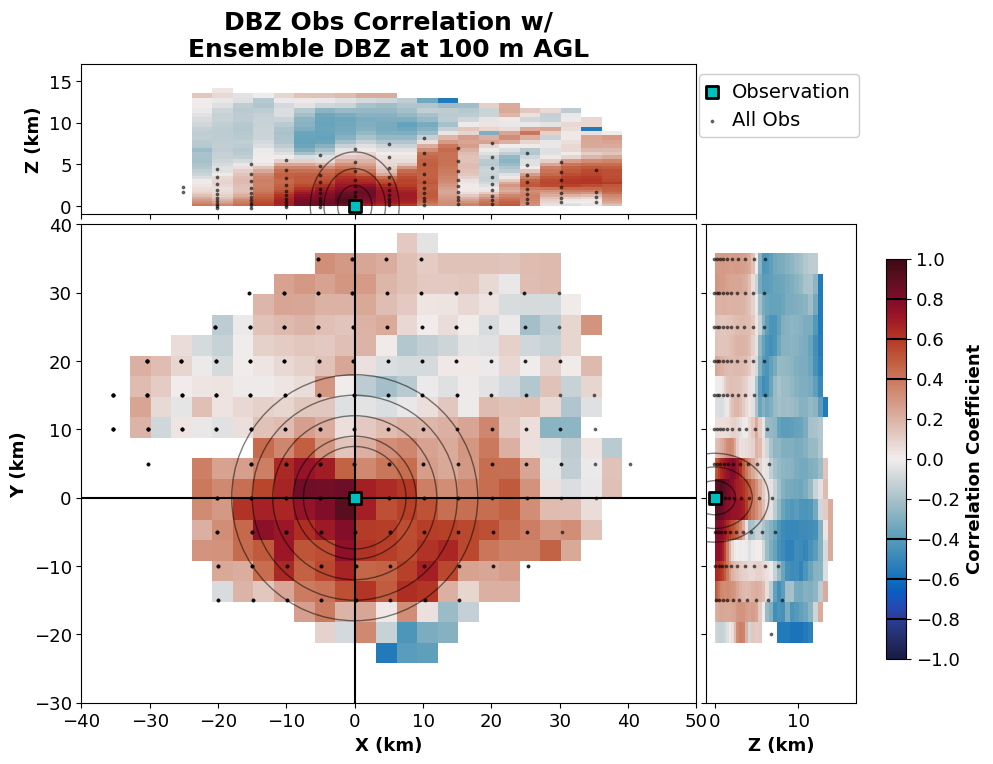

In [170]:
def plot_radar(ax, rx, ry, rs=[10]):

    ax.scatter(rx,ry, color='k')

    for r in rs:
        ax.add_patch(plt.Circle((rx,ry), r, fill=False, edgecolor='k', alpha=0.5))
        
from mpl_toolkits.axes_grid1 import make_axes_locatable
def make_plan_plot():
    fig, main_ax = plt.subplots(figsize=(10,10), facecolor='none')
    divider = make_axes_locatable(main_ax)
    top_ax = divider.append_axes("top", 1.5, pad=0.1, sharex=main_ax)
    right_ax = divider.append_axes("right", 1.5, pad=0.1, sharey=main_ax)

    # make some labels invisible
    top_ax.xaxis.set_tick_params(labelbottom=False)
    right_ax.yaxis.set_tick_params(labelleft=False)

    main_ax.set_xlabel('X (km)')
    main_ax.set_ylabel('Y (km)')
    top_ax.set_ylabel( 'Z (km)')
    right_ax.set_xlabel('Z (km)')
    main_ax.set_aspect('equal')
    
    return fig, main_ax, right_ax, top_ax



fig, main_ax, right_ax, top_ax =make_plan_plot()


top_ax.pcolormesh(xh3[:,0,:]-x_i, zh3[:,0,:], cors[:, crossy, :], vmin = -1, vmax = 1, cmap=cmaps.balance)
right_ax.pcolormesh(zh3[:,:,0], yh3[:,:,0]-y_i, cors[:, :,crossx], vmin = -1, vmax = 1, cmap=cmaps.balance)

im=main_ax.pcolormesh(xh-x_i, yh-y_i, cors[z_ens], vmin = -1, vmax = 1, cmap=cmaps.balance)


for ax in [main_ax, right_ax, top_ax]: ax.scatter(0,0, color='c', ec='k', s=80, linewidth=2, marker='s', label='Observation', zorder=100)
    
plot_radar(main_ax, 0,0, [7.5, 9, 12, 15, 18])
plot_radar(top_ax, 0,0, [2.5, 4.5, 6.5])
plot_radar(right_ax, 0,0, [2.5, 4.5, 6.5])


main_ax.set_xlim(-40,50)
main_ax.set_ylim(-30,40)
top_ax.set_ylim(-1, 17)
right_ax.set_xlim(-1, 17)


main_ax.scatter(xob[ti, (ref_value[ti] >= 20) & (abs((zob[ti]/1000 - z_i)) < 1)]/1000 - x_i, yob[ti,(ref_value[ti] >= 20) & (abs((zob[ti]/1000 - z_i)) < 1)]/1000 - y_i, 
    color='k', s=3, alpha=0.5, label=f'All Obs')

top_ax.scatter(xob[ti, (ref_value[ti] >= 20) & (abs((yob[ti]/1000 - y_i)) < 1) ]/1000 - x_i, zob[ti,(ref_value[ti] >= 20) & (abs((yob[ti]/1000 - y_i)) <1) ]/1000 - z_i, 
               color='k', s=3, alpha=0.5, label=f'All Obs')


right_ax.scatter(zob[ti, (ref_value[ti] >= 20) & (abs((xob[ti]/1000 - x_i)) < 1) ]/1000 - z_i, yob[ti,(ref_value[ti] >= 20) & (abs((xob[ti]/1000 - x_i)) <1) ]/1000 - y_i, 
               color='k', s=3, alpha=0.5, label=f'All Obs')
    
top_ax.set_title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')
top_ax.legend(fontsize=14, loc=1, bbox_to_anchor=(1.28, 1), handlelength=.5)


main_ax.axhline(0, color='k')
main_ax.axvline(0, color='k')

cbar_ax = fig.add_axes([0.93, 0.22, 0.02, 0.4])
cbar = plt.colorbar(im,  cax=cbar_ax)
cbar.set_label('Correlation Coefficient', weight='bold')
cbar.set_ticks(np.arange(-1, 1.2, .2))
for lev in [0.4, 0.6, 0.8]:
    cbar.ax.axhline(lev, color='k')
    cbar.ax.axhline(-1*lev, color='k')

W
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600,610,620,630,640,650,660,670,680,690,700,710,720,730,740,750,760,770,780,790,800,810,820,830,840,850,860,870,880,890,900,910,920,930,940,950,960,970,980,990,1000,1010,1020,1030,1040,1050,1060,1070,1080,1090,1100,1110,1120,1130,1140,1150,1160,1170,1180,1190,1200,1210,1220,1230,1240,1250,1260,1270,1280,1290,1300,1310,1320,1330,1340,1350,1360,1370,1380,1390,1400,1410,1420,1430,1440,1450,1460,1470,1480,1490,1500,1510,1520,1530,1540,1550,1560,1570,1580,1590,1600,1610,1620,1630,1640,1650,1660,1670,1680,1690,1700,1710,1720,1730,1740,1750,1760,1770,1780,1790,1800,1810,1820,1830,1840,1850,1860,1870,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020,2030,2040,2050,2060,2070,2080,2090,2100,2110,2120,2130,2140,2150,2160,2170,2180,2190,2200,2210

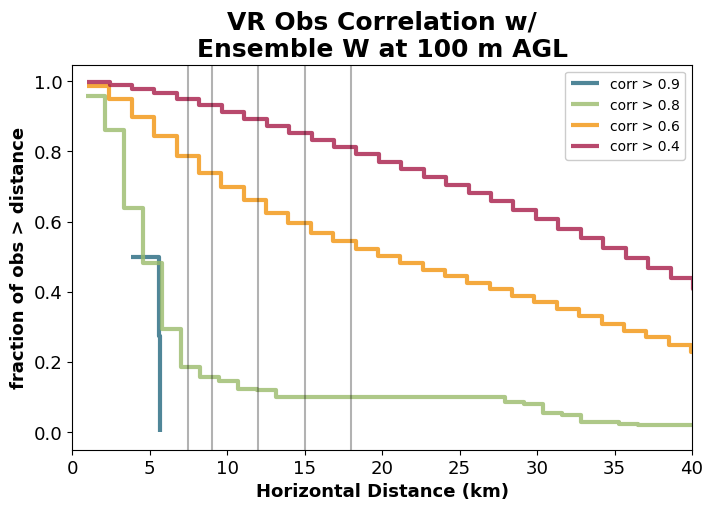

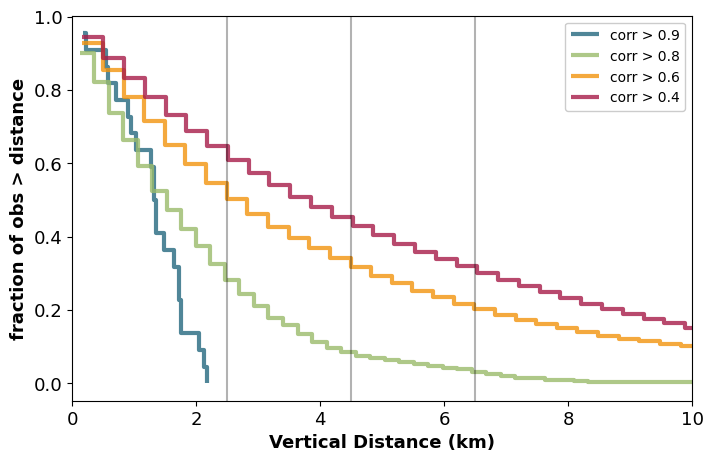

CPU times: user 56min 49s, sys: 1min 14s, total: 58min 3s
Wall time: 57min 50s


In [5]:
%%time


exp = 'C3_5L09_R0_V2'
var = 'VR'


ds = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/AllPrior_Post.nc", decode_timedelta=True)
inlier =False
times_obs = [pd.Timestamp(t) for t in ds.time.values] 


val = get_var(ds, 'value', var, drop_inliers=inlier)
xob = get_var(ds, 'x', var, drop_inliers=inlier)
yob = get_var(ds, 'y', var, drop_inliers=inlier)
zob = get_var(ds, 'z', var, drop_inliers=inlier)

#Hxfbar = get_var(ds, 'Hxfbar', var,drop_inliers=inlier)
Hxf = get_var(ds, 'Hxf', var, drop_inliers=inlier)

#d = val[:,:,np.newaxis] - Hxf
d = Hxf - np.nanmean(Hxf)

ti = findnearest(times_obs, time)

#ens_var = 'DBZ'

for ens_var in [ 'W']:
    print(ens_var)
    full_ens = ens_state[ens_var][:-1,:,:,:]
    ens_pert = full_ens - full_ens.mean() # i guess just use one value? along height may be better though?
    #ens_pert = np.where(full_ens >= 20, ens_pert, np.nan)
    

    
    total_cor   = []
    total_Hdist = []
    total_Vdist = []
    total_dist  = []
    
    for ni in range(len(xob[ti])):
        if ni%10 == 0: print(ni, end=',')
            
        if np.isnan(xob[ti, ni]) ==False:
    
            #ni = 40#405#0
            
            d_i = d[ti, ni, :] # 36 values
            
            x_i = xob[ti, ni]/1000
            y_i = yob[ti, ni]/1000
            z_i = zob[ti, ni]/1000
        
            z_ens = findnearest(ens_state['zc'][:], z_i)
            
            
            ### subset test
            xh, yh =ens_state['xc'][:]/1000,ens_state['yc'][:]/1000
            
            # x1, x0 = findnearest(xh, np.nanmax(xob[ti]/1000) + 20), findnearest(xh, np.nanmin(xob[ti]/1000) - 20)
            # y1, y0 = findnearest(yh, np.nanmax(yob[ti]/1000) + 20), findnearest(yh, np.nanmin(yob[ti]/1000) - 20)
            
            
            x1, x0 = findnearest(xh,x_i+50),findnearest(xh,x_i-50)
            y1, y0 = findnearest(yh,y_i+50),findnearest(yh,y_i-50)
            
            # for looping
            # don't go above zcutoff (10 km) + vertical localization radius, so 17 km for me, k=39 gives 17.5, k=38 is 16.9km
            zn = np.arange(39)#[findnearest(ens_state['zc'][:], z_i)] #[2]
            xn = np.arange(x0, x1+1)#np.arange(128)
            yn = np.arange(y0, y1+1)#np.arange(128)
            
            cors = np.empty([len(zn), 128, 128])*np.nan
            
            for zz in zn:
                for yy in yn: 
                    for xx in xn:

                        vals = ens_pert[:, zz, yy, xx]
                        #keep = np.where(np.isnan(vals)==False)
                        #cors[zz,yy,xx] = np.corrcoef(d_i[keep], vals[keep])[0,1]
                        cors[zz, yy,xx] = np.corrcoef(d_i, vals)[0,1]
            
            zh, yh, xh = np.meshgrid(ens_state['zc'][:len(zn)]/1000,ens_state['xc'][:]/1000,ens_state['yc'][:]/1000, indexing='ij')
            H_dist = np.hypot(xh - x_i, yh - y_i)
            V_dist = abs(zh - z_i)
            total = np.hypot(xh - x_i, yh - y_i, zh - z_i)
            
            # add to full dataset now
            mask = np.isnan(cors) == False
            total_cor.extend(cors[mask])
            total_Hdist.extend(H_dist[mask])
            total_Vdist.extend(V_dist[mask])
            total_dist.extend(total[mask])
    
    datadict = {'corr': total_cor, 'Hdist':total_Hdist, 'Vdist':total_Vdist, 'totaldist': total_dist}
    df = pd.DataFrame(datadict)
    name = f'{fpath}corr_{var}_{ens_var}.csv'
    df.to_csv(name, index=None)


    colors = cmaps.pride(np.linspace(.2, .8, 4))

    levs = [.9, .8, .6, .4]
    
    fig = plt.figure(figsize=(8, 5))
    for i,lev in enumerate(levs):
    
        mask80 = abs(np.array(total_cor)) >= lev
        data = np.array(total_Hdist)[mask80]
        
        pdf, bin_edges = np.histogram(
           data,        # array of data
           bins=50,    # specify the number of bins for distribution function
           density=True # True to return probability density function (pdf) instead of count
           )
        
        cdf = np.cumsum(pdf*np.diff(bin_edges))
        bins = bin_edges + (bin_edges[1]-bin_edges[0])/2
        plt.plot(bins[:-1], 1-cdf, drawstyle='steps-post' , label=f'corr > {lev}', color=colors[i], lw=3, alpha=0.8)
    for l in [7.5, 9, 12, 15, 18]:
        plt.axvline(l, color='k', alpha=0.3)
    #plt.axhline(.5)
    plt.legend()
    plt.xlim(0, 40)
    plt.xlabel('Horizontal Distance (km)')
    plt.ylabel('fraction of obs > distance')
    plt.title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')
    plt.show()
    
    
    fig = plt.figure(figsize=(8, 5))
    for i,lev in enumerate(levs):
    
        mask80 = abs(np.array(total_cor)) >= lev
        data = np.array(total_Vdist)[mask80]
        
        pdf, bin_edges = np.histogram(
           data,        # array of data
           bins=50,    # specify the number of bins for distribution function
           density=True # True to return probability density function (pdf) instead of count
           )
        
        cdf = np.cumsum(pdf*np.diff(bin_edges))
        bins = bin_edges + (bin_edges[1]-bin_edges[0])/2
        plt.plot(bins[:-1], 1-cdf, drawstyle='steps-post' , label=f'corr > {lev}', color=colors[i], lw=3, alpha=0.8)
    for l in [2.5, 4.5, 6.5]:
        plt.axvline(l, color='k', alpha=0.3)
    #plt.axhline(.5)
    plt.legend()
    plt.xlim(0, 10)
    plt.xlabel('Vertical Distance (km)')
    plt.ylabel('fraction of obs > distance')
    plt.show()

In [110]:
# datadict = {'corr': total_cor, 'Hdist':total_Hdist, 'Vdist':total_Vdist, 'totaldist': total_dist}
# df = pd.DataFrame(datadict)
# name = f'{fpath}corr_{var}_{ens_var}.csv'
# df.to_csv(name, index=None)

In [572]:
name = f'{fpath}corr_{var}_{ens_var}.csv'
name

'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R0_V2/corr_VR_U.csv'

In [533]:
mask80 = abs(np.array(total_cor)) >= 0.8
data = np.array(total_Hdist)[mask80]

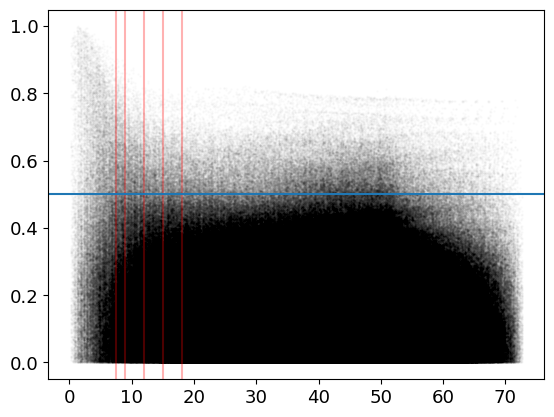

In [564]:
plt.scatter(np.array(total_Hdist),abs(np.array(total_cor)), s=1, alpha=0.01, color='k')
for l in [7.5, 9, 12, 15, 18]:
    plt.axvline(l, color='r', alpha=0.3)
plt.axhline(.5)

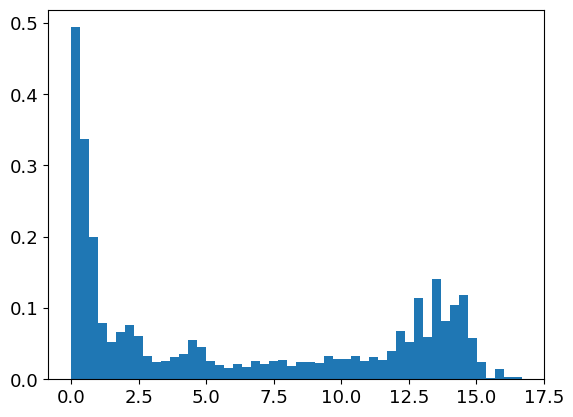

In [565]:
plt.hist(data, bins=50, density=True);#, cumulative=True);

In [577]:
len(total_Hdist)

68831287

Text(0, 0.5, 'fraction of obs > distance')

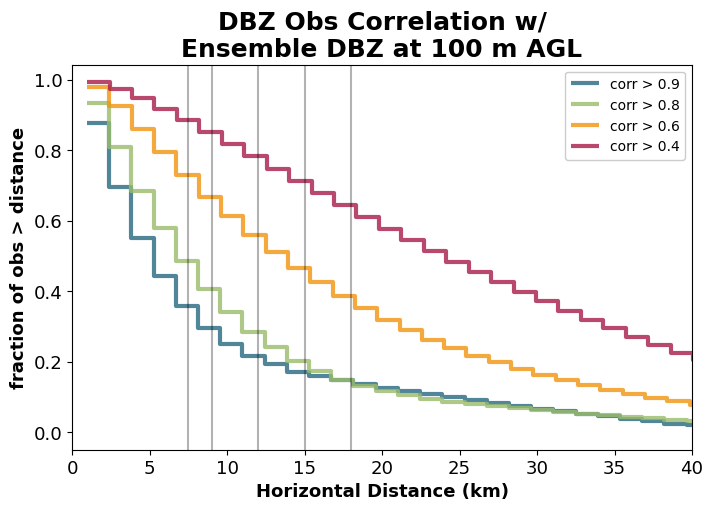

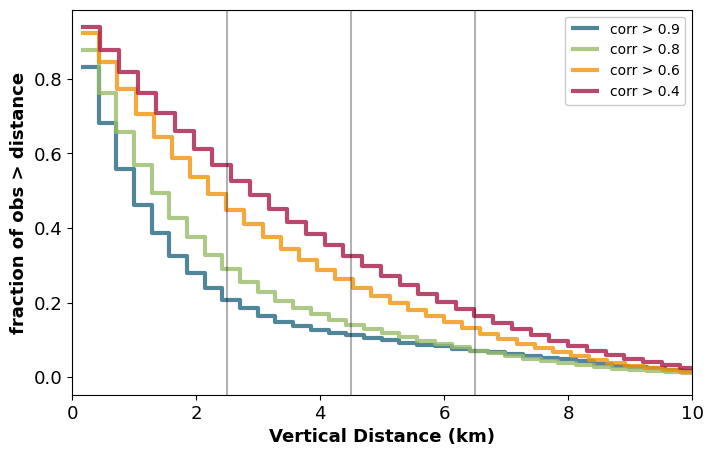

In [576]:
colors = cmaps.pride(np.linspace(.2, .8, 4))

levs = [.9, .8, .6, .4]

fig = plt.figure(figsize=(8, 5))
for i,lev in enumerate(levs):

    mask80 = abs(np.array(total_cor)) >= lev
    data = np.array(total_Hdist)[mask80]
    
    pdf, bin_edges = np.histogram(
       data,        # array of data
       bins=50,    # specify the number of bins for distribution function
       density=True # True to return probability density function (pdf) instead of count
       )
    
    cdf = np.cumsum(pdf*np.diff(bin_edges))
    bins = bin_edges + (bin_edges[1]-bin_edges[0])/2
    plt.plot(bins[:-1], 1-cdf, drawstyle='steps-post' , label=f'corr > {lev}', color=colors[i], lw=3, alpha=0.8)
for l in [7.5, 9, 12, 15, 18]:
    plt.axvline(l, color='k', alpha=0.3)
#plt.axhline(.5)
plt.legend()
plt.xlim(0, 40)
plt.xlabel('Horizontal Distance (km)')
plt.ylabel('fraction of obs > distance')
plt.title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')




fig = plt.figure(figsize=(8, 5))
for i,lev in enumerate(levs):

    mask80 = abs(np.array(total_cor)) >= lev
    data = np.array(total_Vdist)[mask80]
    
    pdf, bin_edges = np.histogram(
       data,        # array of data
       bins=50,    # specify the number of bins for distribution function
       density=True # True to return probability density function (pdf) instead of count
       )
    
    cdf = np.cumsum(pdf*np.diff(bin_edges))
    bins = bin_edges + (bin_edges[1]-bin_edges[0])/2
    plt.plot(bins[:-1], 1-cdf, drawstyle='steps-post' , label=f'corr > {lev}', color=colors[i], lw=3, alpha=0.8)
for l in [2.5, 4.5, 6.5]:
    plt.axvline(l, color='k', alpha=0.3)
#plt.axhline(.5)
plt.legend()
plt.xlim(0, 10)
plt.xlabel('Vertical Distance (km)')
plt.ylabel('fraction of obs > distance')

(-29.74999803863443, 210.25000196136557)

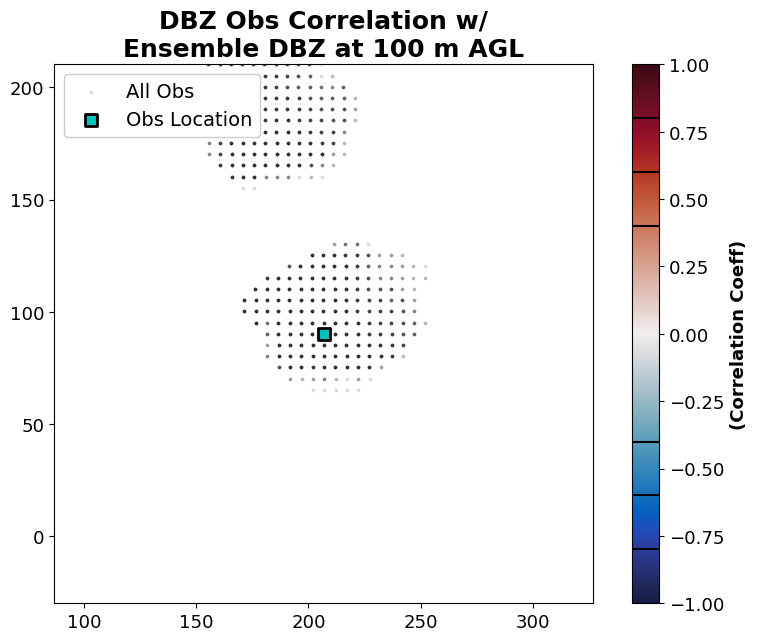

In [111]:


xh, yh = np.meshgrid(ens_state['xc'][:]/1000,ens_state['yc'][:]/1000)

fig, ax = plt.subplots(1,1,figsize=(10,7))
ax.set_aspect('equal')

#im=plt.pcolormesh(xh, yh, abs(cors), vmin = 0, vmax = 1, cmap=cmaps.red2b)
im=plt.pcolormesh(xh, yh, cors[z_ens], vmin = -1, vmax = 1, cmap=cmaps.balance)

plt.contour(xh, yh, abs(cors[z_ens]),levels=[0.4, 0.6, 0.8], colors='k', linewidths=1)

plt.scatter(xob[ti]/1000, yob[ti]/1000, color='k', s=3, alpha=0.1, label=f'All Obs')

plt.scatter(x_i, y_i , color='c', ec='k', s=80, linewidth=2, marker='s', label='Obs Location', zorder=100)


cbar = plt.colorbar(im)
cbar.set_label('(Correlation Coeff)', weight='bold')
for lev in [0.4, 0.6, 0.8]:
    cbar.ax.axhline(lev, color='k')
    cbar.ax.axhline(-1*lev, color='k')
    
plt.title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')
plt.legend(fontsize=14, loc=2)

plt.xlim(x_i-120, x_i+120)
plt.ylim(y_i-120, y_i+120)

# plt.xlim(xh_ob-80, xh_ob+80)
# plt.ylim(yh_ob-80, yh_ob+80)

(-29.74999803863443, 210.25000196136557)

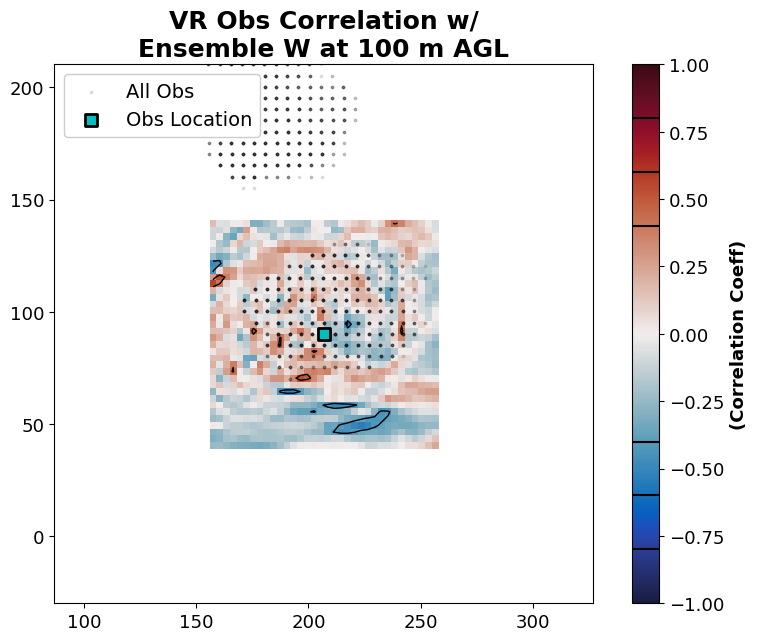

In [483]:


xh, yh = np.meshgrid(ens_state['xc'][:]/1000,ens_state['yc'][:]/1000)

fig, ax = plt.subplots(1,1,figsize=(10,7))
ax.set_aspect('equal')

#im=plt.pcolormesh(xh, yh, abs(cors), vmin = 0, vmax = 1, cmap=cmaps.red2b)
im=plt.pcolormesh(xh, yh, cors[z_ens], vmin = -1, vmax = 1, cmap=cmaps.balance)

plt.contour(xh, yh, abs(cors[z_ens]),levels=[0.4, 0.6, 0.8], colors='k', linewidths=1)

plt.scatter(xob[ti]/1000, yob[ti]/1000, color='k', s=3, alpha=0.1, label=f'All Obs')

plt.scatter(x_i, y_i , color='c', ec='k', s=80, linewidth=2, marker='s', label='Obs Location', zorder=100)


cbar = plt.colorbar(im)
cbar.set_label('(Correlation Coeff)', weight='bold')
for lev in [0.4, 0.6, 0.8]:
    cbar.ax.axhline(lev, color='k')
    cbar.ax.axhline(-1*lev, color='k')
    
plt.title(f'{var} Obs Correlation w/\nEnsemble {ens_var} at {ens_state["zc"][:][z_ens]:.0f} m AGL')
plt.legend(fontsize=14, loc=2)

plt.xlim(x_i-120, x_i+120)
plt.ylim(y_i-120, y_i+120)

# plt.xlim(xh_ob-80, xh_ob+80)
# plt.ylim(yh_ob-80, yh_ob+80)

In [271]:
zh, yh, xh = np.meshgrid(ens_state['zc'][:]/1000,ens_state['xc'][:]/1000,ens_state['yc'][:]/1000, indexing='ij')

In [280]:
H_dist = np.hypot(xh - xh_ob, yh - yh_ob)

In [305]:
H_dist = np.hypot(xh - xh_ob, yh - yh_ob)
V_dist = abs(zh - z_i/1000)
total = np.hypot(xh - xh_ob, yh - yh_ob, zh - z_i/1000)

In [57]:
xx = findnearest(ens_state['xc'][:]/1000, 115)
yy = findnearest(ens_state['yc'][:]/1000, 130)
zz = 2

np.corrcoef(d_i, ens_pert[:, zz, yy, xx])[0,1]

np.float64(-0.7935637790828388)

In [282]:
z_i/1000

np.float64(0.9255622820648685)

In [112]:
ens_state['zc'][:]

array([  100.     ,   306.66666,   526.6667 ,   760.     ,  1006.6666 ,
        1266.6667 ,  1540.0001 ,  1826.6667 ,  2126.6667 ,  2440.     ,
        2766.667  ,  3106.6667 ,  3460.     ,  3826.6665 ,  4206.667  ,
        4600.     ,  5006.6665 ,  5426.6665 ,  5860.     ,  6306.667  ,
        6766.667  ,  7240.     ,  7726.667  ,  8226.667  ,  8740.     ,
        9266.666  ,  9806.666  , 10360.     , 10926.667  , 11506.667  ,
       12100.     , 12700.     , 13300.     , 13900.     , 14500.     ,
       15100.     , 15700.     , 16300.     , 16900.     , 17500.     ,
       18100.     , 18700.     , 19300.     , 19900.     , 20500.     ,
       21100.     , 21700.     , 22300.     , 22900.     , 23500.     ,
       24100.     , 24700.     ], dtype=float32)

In [113]:
findnearest(ens_state['zc'][:], z_i)

np.int64(7)

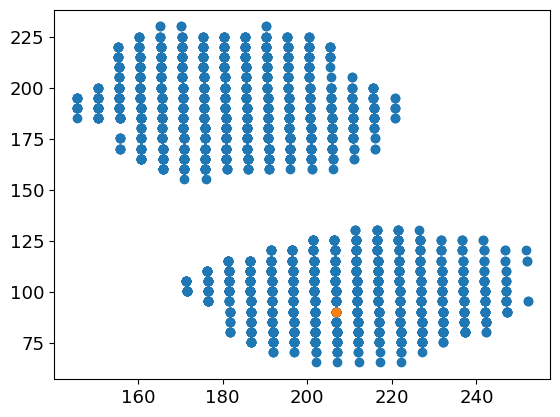

In [404]:
plt.scatter(xob[ti]/1000, yob[ti]/1000)
ni=40
plt.scatter(xob[ti, ni]/1000, yob[ti, ni]/1000)

In [47]:
# Example with two 1-D arrays
x = np.array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
y = np.array([2, 1, 4, 5, 8, 12, 18, 25, 96, 48])
correlation_matrix = np.corrcoef(x, y)
print(correlation_matrix)

[[1.         0.75864029]
 [0.75864029 1.        ]]


In [33]:
ds

<xarray.Dataset> Size: 242MB
Dimensions:       (t: 31, ne: 36, n: 10353)
Coordinates:
  * t             (t) int64 248B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * ne            (ne) int64 288B 0 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34 35
  * n             (n) int64 83kB 0 1 2 3 4 5 ... 10348 10349 10350 10351 10352
Data variables: (12/28)
    secs          (t, n) float64 3MB ...
    kind          (t, n) float64 3MB ...
    year          (t, n) float64 3MB ...
    month         (t, n) float64 3MB ...
    day           (t, n) float64 3MB ...
    hour          (t, n) float64 3MB ...
    ...            ...
    DBZ           (t, n) bool 321kB ...
    VR            (t, n) bool 321kB ...
    DBZ0          (t, n) bool 321kB ...
    Hxf_post      (t, n, ne) float64 92MB ...
    Hxfbar_post   (t, n) float64 3MB ...
    outlier_post  (t, n) float64 3MB ...